In [891]:
# Loading stuff

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.ensemble import RandomForestClassifier

In [892]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [893]:
# --- Loading all the datasets
# Train dataset
train_dataset = pd.read_csv('data/train_radiomics_hipocamp.csv')
# Test dataset
test_dataset = pd.read_csv('data/test_radiomics_hipocamp.csv')

In [894]:
# --- Exploring the train dataset
print(f"DS SHAPE\n{train_dataset.shape}\n")
print(f"DATA TYPE\n{train_dataset.dtypes.value_counts()}\n")
object_columns = train_dataset.select_dtypes(include='object').columns
print(f"OBJECT COLUMNS\n{object_columns.tolist()}\n")
missing_summary = train_dataset.isnull().sum()
print(f"MISSING VALUES\n{(missing_summary > 0).sum()}\n")
print(train_dataset['Transition'].value_counts(normalize=True))
unique_counts = train_dataset.nunique()
print(f"\nUNIQUE VALUE COLUMN\n{(unique_counts == 1).sum()}")

DS SHAPE
(305, 2181)

DATA TYPE
float64    2014
int64       147
object       20
Name: count, dtype: int64

OBJECT COLUMNS
['ID', 'Image', 'Mask', 'diagnostics_Versions_PyRadiomics', 'diagnostics_Versions_Numpy', 'diagnostics_Versions_SimpleITK', 'diagnostics_Versions_PyWavelet', 'diagnostics_Versions_Python', 'diagnostics_Configuration_Settings', 'diagnostics_Configuration_EnabledImageTypes', 'diagnostics_Image-original_Hash', 'diagnostics_Image-original_Spacing', 'diagnostics_Image-original_Size', 'diagnostics_Mask-original_Hash', 'diagnostics_Mask-original_Spacing', 'diagnostics_Mask-original_Size', 'diagnostics_Mask-original_BoundingBox', 'diagnostics_Mask-original_CenterOfMassIndex', 'diagnostics_Mask-original_CenterOfMass', 'Transition']

MISSING VALUES
0

Transition
CN-CN      0.314754
MCI-MCI    0.232787
MCI-AD     0.222951
AD-AD      0.196721
CN-MCI     0.032787
Name: proportion, dtype: float64

UNIQUE VALUE COLUMN
159


In [895]:
# --- Removing columns with irrelevant information

# Getting all columns whose value is an object
obj_col = train_dataset.select_dtypes(include='object').columns

# Storing in a list the columns that have the same number of unique values as the number of rows
# This means that the column is a unique identifier and probably should be dropped
unique_cols = [col for col in obj_col if train_dataset[col].nunique() == train_dataset.shape[0]]

# list of columns that will be dropped
print(f"DS SHAPE\n{train_dataset.shape}\n")
print(f"UNIQUE COLUMNS\n{unique_cols}\n")

# The following features might actually be useful:
cols_to_keep = [
    'diagnostics_Mask-original_BoundingBox',
    'diagnostics_Mask-original_CenterOfMassIndex',
    'diagnostics_Mask-original_CenterOfMass'
]

# removing last 3 columns from the 'unique_cols' - we don't want to drop them
unique_cols = [col for col in unique_cols if col not in cols_to_keep]

# Dropping the columns stored in the unique_cols list
train_dataset.drop(columns=unique_cols, inplace=True)
# Dropping them from the test dataset as well
test_dataset.drop(columns=unique_cols, inplace=True)

pd.set_option('display.max_colwidth', None)
display(train_dataset['diagnostics_Mask-original_BoundingBox'])
display(train_dataset['diagnostics_Mask-original_CenterOfMassIndex'].head())
display(train_dataset['diagnostics_Mask-original_CenterOfMass'].head())
print(f"\nDS SHAPE\n{train_dataset.shape}")

DS SHAPE
(305, 2181)

UNIQUE COLUMNS
['ID', 'Image', 'Mask', 'diagnostics_Image-original_Hash', 'diagnostics_Mask-original_Hash', 'diagnostics_Mask-original_BoundingBox', 'diagnostics_Mask-original_CenterOfMassIndex', 'diagnostics_Mask-original_CenterOfMass']



,diagnostics_Mask-original_BoundingBox
0,"(103, 113, 93, 36, 30, 71)"
1,"(81, 127, 93, 47, 16, 73)"
2,"(77, 119, 89, 49, 30, 81)"
3,"(93, 102, 90, 41, 29, 78)"
4,"(87, 119, 91, 40, 27, 75)"
...,...
300,"(88, 118, 89, 41, 25, 78)"
301,"(103, 103, 93, 38, 27, 70)"
302,"(80, 131, 89, 48, 17, 82)"
303,"(93, 103, 91, 40, 31, 75)"


,diagnostics_Mask-original_CenterOfMassIndex
0,"(121.94230227976358, 129.27272727272728, 128.40402476780187)"
1,"(107.06170458927883, 135.28088443244633, 128.27458542229078)"
2,"(103.3640972118682, 135.28164604144922, 128.98628298792306)"
3,"(116.29827315541601, 118.67431469629271, 129.3098659582176)"
4,"(108.26561977948546, 132.05462746408287, 127.67206815903775)"


,diagnostics_Mask-original_CenterOfMass
0,"(121.94230227976358, 129.27272727272728, 128.40402476780187)"
1,"(107.06170458927883, 135.28088443244633, 128.27458542229078)"
2,"(103.3640972118682, 135.28164604144922, 128.98628298792306)"
3,"(116.29827315541601, 118.67431469629271, 129.3098659582176)"
4,"(108.26561977948546, 132.05462746408287, 127.67206815903775)"



DS SHAPE
(305, 2176)


In [896]:
# Check if 'diagnostics_Mask-original_CenterOfMassIndex' and 'diagnostics_Mask-original_CenterOfMass' are the same
# If they are, we can drop one of them

print(f"DS SHAPE\n{train_dataset.shape}\n")
are_equal = ((train_dataset['diagnostics_Mask-original_CenterOfMassIndex'] == train_dataset['diagnostics_Mask-original_CenterOfMass']).all())
print(f"ARE EQUAL: {are_equal}\n")

# They are the same, so we can drop one of them
train_dataset.drop('diagnostics_Mask-original_CenterOfMass', axis=1, inplace=True)
test_dataset.drop('diagnostics_Mask-original_CenterOfMass', axis=1, inplace=True)
print(f"DS SHAPE\n{train_dataset.shape}")

DS SHAPE
(305, 2176)

ARE EQUAL: True

DS SHAPE
(305, 2175)


In [897]:
# --- Transfoming the 'diagnostics_Mask-original_BoundingBox' feature into useful data

print(f"DS SHAPE\n{train_dataset.shape}\n")

# Splitting the string into 6 different columns
# probably x,y,z,width,height,depth -> most common

train_dataset['diagnostics_Mask-original_BoundingBox'] = train_dataset['diagnostics_Mask-original_BoundingBox'].str.replace('(', '').str.replace(')', '')
train_dataset['diagnostics_Mask-original_BoundingBox'] = train_dataset['diagnostics_Mask-original_BoundingBox'].str.split(',').apply(lambda x: [int(i) for i in x])
train_dataset[['x', 'y', 'z', 'width', 'height', 'depth']] = pd.DataFrame(train_dataset['diagnostics_Mask-original_BoundingBox'].tolist(), index=train_dataset.index)
train_dataset.drop('diagnostics_Mask-original_BoundingBox', axis=1, inplace=True)

# Doing the same for the test dataset
test_dataset['diagnostics_Mask-original_BoundingBox'] = test_dataset['diagnostics_Mask-original_BoundingBox'].str.replace('(', '').str.replace(')', '')
test_dataset['diagnostics_Mask-original_BoundingBox'] = test_dataset['diagnostics_Mask-original_BoundingBox'].str.split(',').apply(lambda x: [int(i) for i in x])
test_dataset[['x', 'y', 'z', 'width', 'height', 'depth']] = pd.DataFrame(test_dataset['diagnostics_Mask-original_BoundingBox'].tolist(), index=test_dataset.index)
test_dataset.drop('diagnostics_Mask-original_BoundingBox', axis=1, inplace=True)

# Calculating the volume of the bounding box
train_dataset['volume'] = train_dataset['width'] * train_dataset['height'] * train_dataset['depth']
test_dataset['volume'] = test_dataset['width'] * test_dataset['height'] * test_dataset['depth']
print(f"DS SHAPE\n{train_dataset.shape}")

DS SHAPE
(305, 2175)

DS SHAPE
(305, 2181)


In [898]:
# --- Transfoming the 'diagnostics_Mask-original_CenterOfMassIndex' feature into useful data

print(f"DS SHAPE\n{train_dataset.shape}\n")

# Splitting the string into 3 different columns

# Removing '(' and ')' from the string
train_dataset['diagnostics_Mask-original_CenterOfMassIndex'] = train_dataset['diagnostics_Mask-original_CenterOfMassIndex'].str.replace('(', '').str.replace(')', '')
train_dataset['diagnostics_Mask-original_CenterOfMassIndex'] = train_dataset['diagnostics_Mask-original_CenterOfMassIndex'].str.split(',').apply(lambda x: [float(i) for i in x])
train_dataset[['x_center', 'y_center', 'z_center']] = pd.DataFrame(train_dataset['diagnostics_Mask-original_CenterOfMassIndex'].tolist(), index=train_dataset.index)
train_dataset.drop('diagnostics_Mask-original_CenterOfMassIndex', axis=1, inplace=True)

# Doing the same for the test dataset
test_dataset['diagnostics_Mask-original_CenterOfMassIndex'] = test_dataset['diagnostics_Mask-original_CenterOfMassIndex'].str.replace('(', '').str.replace(')', '')
test_dataset['diagnostics_Mask-original_CenterOfMassIndex'] = test_dataset['diagnostics_Mask-original_CenterOfMassIndex'].str.split(',').apply(lambda x: [float(i) for i in x])
test_dataset[['x_center', 'y_center', 'z_center']] = pd.DataFrame(test_dataset['diagnostics_Mask-original_CenterOfMassIndex'].tolist(), index=test_dataset.index)
test_dataset.drop('diagnostics_Mask-original_CenterOfMassIndex', axis=1, inplace=True)

# Calculating the distance from the center of mass to the bounding box
train_dataset['distance'] = np.sqrt((train_dataset['x'] - train_dataset['x_center'])**2 + (train_dataset['y'] - train_dataset['y_center'])**2 + (train_dataset['z'] - train_dataset['z_center'])**2)
test_dataset['distance'] = np.sqrt((test_dataset['x'] - test_dataset['x_center'])**2 + (test_dataset['y'] - test_dataset['y_center'])**2 + (test_dataset['z'] - test_dataset['z_center'])**2)
print(f"DS SHAPE\n{train_dataset.shape}")

DS SHAPE
(305, 2181)

DS SHAPE
(305, 2184)


In [899]:
print(f"DS SHAPE\n{train_dataset.shape}\n")

# --- Dropping constant features
train_dataset = train_dataset.loc[:, (train_dataset != train_dataset.iloc[0]).any()]

# Dropping the same columns on the test dataset
test_dataset = test_dataset[train_dataset.drop(columns='Transition').columns]

print(f"DS SHAPE\n{train_dataset.shape}")

DS SHAPE
(305, 2184)

DS SHAPE
(305, 2025)


In [900]:
# --- Checking all unique values in the Transition column
train_dataset['Transition'].value_counts()
# Dataset is extremely UNBALANCED

,count
Transition,
CN-CN,96
MCI-MCI,71
MCI-AD,68
AD-AD,60
CN-MCI,10


In [901]:
# --- Using encoding to transform the target columns into numeric values

replace_map = {'Transition': {'CN-CN': 0, 'AD-AD': 1, 'CN-MCI': 2, 'MCI-AD': 3, 'MCI-MCI': 4}}
print(f"TRANSITION BEFORE ENCODING:\n{train_dataset['Transition'].head()}\n")
train_dataset = train_dataset.replace(replace_map)
test_dataset = test_dataset.replace(replace_map)
print(f"TRANSITION AFTER ENCODING:\n{train_dataset['Transition'].head()}")

TRANSITION BEFORE ENCODING:
0     CN-CN
1     CN-CN
2     AD-AD
3    CN-MCI
4     CN-CN
Name: Transition, dtype: object

TRANSITION AFTER ENCODING:
0    0
1    0
2    1
3    2
4    0
Name: Transition, dtype: int64


<ipython-input-901-b6c8d1f523a7>:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_dataset = train_dataset.replace(replace_map)


In [902]:
train_dataset['Transition'].value_counts()

,count
Transition,
0,96
4,71
3,68
1,60
2,10


In [903]:
# --- Dropping non-target columns with the same info (correlation = 1 between them)

print(f"DS SHAPE\n{train_dataset.shape}\n")
target_column = 'Transition'
# Calculating the correlation matrix (excluding the target column)
train_dataset_tmp = train_dataset
corr_matrix_train = train_dataset_tmp.drop(columns=[target_column]).corr().abs()

# Upper triangle matrix of correlations
upper = corr_matrix_train.where(np.triu(np.ones(corr_matrix_train.shape), k=1).astype(bool))

# Finding index of feature columns with correlation equal to 1
threshold = 1.0
to_drop = [column for column in upper.columns if any(upper[column] >= threshold)] # for some reason there are columns with correlation > 1.0
print("DROPPING " + str(len(to_drop)) + " COLUMNS\n")

# Dropping the columns
train_dataset = train_dataset.drop(columns=to_drop)
test_dataset = test_dataset.drop(columns=to_drop)
print(f"DS SHAPE\n{train_dataset.shape}")

DS SHAPE
(305, 2025)

DROPPING 137 COLUMNS

DS SHAPE
(305, 1888)


In [904]:
## --- Dropping columns with low correlation with the target column (<0.005)

print(f"DS SHAPE\n{train_dataset.shape}\n")
corr_matrix = train_dataset.corr()
corr_target = corr_matrix['Transition'].abs()
uncorr_cols = []
for i in range(len(corr_target)):
  if corr_target.iloc[i] < 0.005:
    uncorr_cols.append(corr_matrix.columns[i])

# Dropping the columns stored in the uncorr_cols list
n_cols_before = len(train_dataset.columns)
train_dataset.drop(uncorr_cols, axis=1, inplace=True)
test_dataset.drop(uncorr_cols, axis=1, inplace=True)
n_cols_after = len(train_dataset.columns)

print("DROPPED " + str(n_cols_before-n_cols_after) + " COLUMNS!\n")
print(f"DS SHAPE\n{train_dataset.shape}")

DS SHAPE
(305, 1888)

DROPPED 75 COLUMNS!

DS SHAPE
(305, 1813)


Axes(0.125,0.11;0.775x0.77)


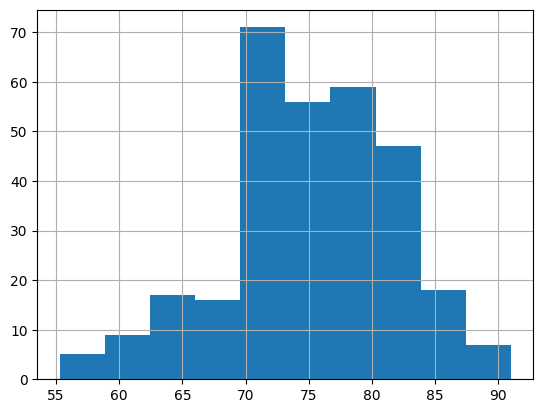

In [905]:
# --- Checking Age column
print(train_dataset['Age'].hist())
plt.show()
# Not a normal distribution

In [906]:
# --- Checking Sex column
print(train_dataset['Sex'].value_counts(normalize=True))
# Not quite balanced

Sex
1    0.567213
0    0.432787
Name: proportion, dtype: float64


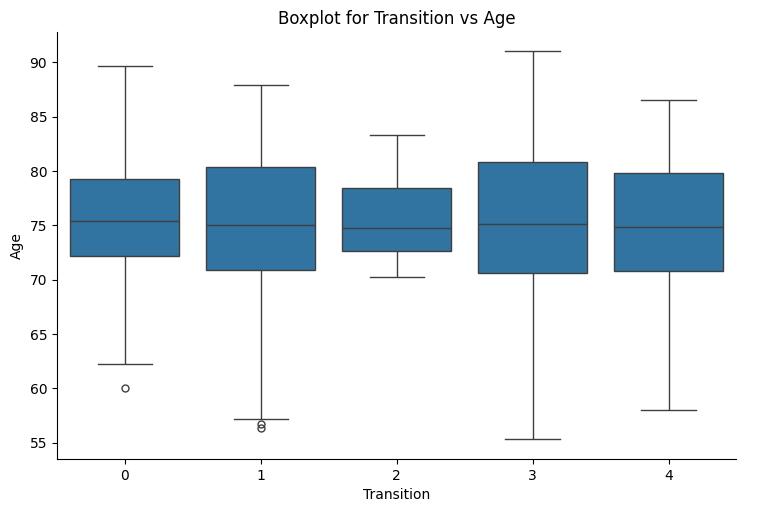

In [907]:
# --- Understanding the relationship between Age and Transition
sns.catplot(x="Transition", y="Age", data=train_dataset, kind="box", aspect=1.5)
plt.title("Boxplot for Transition vs Age")
plt.show()

In [908]:
# --- Treating outliers
# Outliers should be converted to the closest bound

print(f"DS SHAPE\n{train_dataset.shape}\n")

changes_count = 0

for col in train_dataset.columns:
    if col not in ['Transition', 'ID']:
        median = train_dataset[col].median()
        q1 = train_dataset[col].quantile(0.25)
        q3 = train_dataset[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Count outliers before replacing them
        changes_count += ((train_dataset[col] < lower_bound) | (train_dataset[col] > upper_bound)).sum()
        changes_count += ((test_dataset[col] < lower_bound) | (test_dataset[col] > upper_bound)).sum()

        # Replace outliers with the median
        # train_dataset[col] = train_dataset[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)
        # test_dataset[col] = test_dataset[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)

        # Replace outliers with the closest bound
        train_dataset[col] = train_dataset[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)
        test_dataset[col] = test_dataset[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

print(f"TOTAL NUMBER OF CHANGES MADE: {changes_count}\n")
print(f"DS SHAPE\n{train_dataset.shape}")

DS SHAPE
(305, 1813)

TOTAL NUMBER OF CHANGES MADE: 23197

DS SHAPE
(305, 1813)


In [909]:
# --- Standardizing data

# Use the same scaler for both datasets

print(f"DS SHAPE\n{train_dataset.shape}\n")

scaler = StandardScaler()
columns_to_scale = train_dataset.drop(columns=['Transition']).columns
train_dataset[columns_to_scale] = scaler.fit_transform(train_dataset[columns_to_scale])
test_dataset[columns_to_scale] = scaler.transform(test_dataset[columns_to_scale])

print(f"DS SHAPE\n{train_dataset.shape}")

DS SHAPE
(305, 1813)

DS SHAPE
(305, 1813)


In [910]:
# Add an 'oversampled' column to the dataset with 'NO' values
# This will be used to guarantee oversampling data is not used in testing
oversampled_column = pd.Series('NO', index=train_dataset.index, name='oversampled')
train_dataset = pd.concat([train_dataset, oversampled_column], axis=1)

In [911]:
# Checking number of samples per class
train_dataset['Transition'].value_counts()

,count
Transition,
0,96
4,71
3,68
1,60
2,10


In [912]:
# --- Oversampling data
### Oversampling should be done after standardizing but before feature selection and dimensionality reduction

print(f"DS SHAPE\n{train_dataset.shape}\n")
print("CLASS DISTRIBUTION BEFORE SMOTE OVERSAMPLING:\n")
print(train_dataset['Transition'].value_counts())

# Split the dataset into features and target
X = train_dataset.drop(columns=['Transition', 'oversampled'])
y = train_dataset['Transition']

# Identify the majority class count (class '0')
majority_class_count = y.value_counts().loc[0]

# Define the sampling strategy
sampling_strategy = {2: int(majority_class_count * 0.3)
#                     1: target_class_1_count,
#                     3: target_class_3_count,
#                     4: target_class_4_count
}

# Apply SMOTE with the defined strategy
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=123)
X_smote, y_smote = smote.fit_resample(X, y)

# Create a new dataframe with the oversampled data
oversampled_data = pd.concat([X_smote, y_smote], axis=1)
oversampled_data.columns = list(X.columns) + ['Transition']

# Mark the oversampled rows with 'YES' in the 'oversampled' column
oversampled_data['oversampled'] = ['YES' if idx >= len(X) else 'NO' for idx in range(len(X_smote))]

# Concatenate the new oversampled data with the original data
train_dataset = pd.concat([train_dataset, oversampled_data[oversampled_data['oversampled'] == 'YES']], ignore_index=True)

# Display the final class distribution for verification
print("\nCLASS DISTRIBUTION AFTER SMOTE OVERSAMPLING:\n")
print(train_dataset['Transition'].value_counts())

# --- Getting the number of normal and oversampled data
train_dataset['oversampled'].value_counts()

DS SHAPE
(305, 1814)

CLASS DISTRIBUTION BEFORE SMOTE OVERSAMPLING:

Transition
0    96
4    71
3    68
1    60
2    10
Name: count, dtype: int64

CLASS DISTRIBUTION AFTER SMOTE OVERSAMPLING:

Transition
0    96
4    71
3    68
1    60
2    28
Name: count, dtype: int64


,count
oversampled,
NO,305
YES,18


In [913]:
## --- Feature selection with ANOVA

print(f"DS SHAPE\n{train_dataset.shape}\n")
X = train_dataset.drop(columns=['Transition', 'oversampled'])
y = train_dataset['Transition']
X = X.loc[:, (X != X.iloc[0]).any()]
print(f"DS SHAPE\n{X.shape}\n")
f, p = f_classif(X, y)
feature_importances = pd.Series(f, index=X.columns)
print(f"MOST IMPORTANT FEATURES\n\n{feature_importances.sort_values(ascending=False).head(10)}\n")
num_features_to_keep = 500
features_to_keep = X.columns[f.argsort()[-num_features_to_keep:]]
X = X[list(features_to_keep)]
test_dataset = test_dataset[features_to_keep]
print(f"DS SHAPE\n{X.shape}")

DS SHAPE
(323, 1814)

DS SHAPE
(323, 1810)

MOST IMPORTANT FEATURES

lbp-2D_glrlm_ShortRunEmphasis                            52.253089
wavelet-LHH_gldm_DependenceNonUniformityNormalized       52.170237
lbp-2D_gldm_DependenceVariance                           50.330542
exponential_glrlm_ShortRunLowGrayLevelEmphasis           50.326411
wavelet-LHH_gldm_DependenceVariance                      48.189443
lbp-2D_gldm_SmallDependenceEmphasis                      48.072664
wavelet-HHH_gldm_SmallDependenceEmphasis                 45.486567
wavelet-LHH_gldm_DependenceEntropy                       45.181146
wavelet-HHH_gldm_SmallDependenceHighGrayLevelEmphasis    44.400159
original_shape_SurfaceVolumeRatio                        43.449634
dtype: float64

DS SHAPE
(323, 500)


In [914]:
## --- Dimensionality reduction with PCA
#
#pca = PCA(n_components=100)
#pca.fit(X)
#data = pca.transform(X)
#train_dataset_no_target = pd.DataFrame(data)
#train_dataset = pd.concat([train_dataset_no_target, train_dataset['Transition'], train_dataset['oversampled']], axis=1)
#
#data_test = pca.transform(test_dataset)
#test_dataset = pd.DataFrame(data_test)

In [926]:
# --- Checking feature importance for the engineered features

X = train_dataset.drop(columns=['Transition', 'oversampled'])
y = train_dataset['Transition']

# Use RandomForest for feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=123)
rf.fit(X, y)
importances = rf.feature_importances_
importance_indices = importances.argsort()[::-1]
top_features = X.columns[importance_indices[:20]]
top_importances = importances[importance_indices[:20]]
features_to_keep = X.columns[importance_indices]

feature_names = ['volume', 'distance', 'x', 'y', 'z', 'width', 'height', 'depth', 'x_center', 'y_center', 'z_center']

print("20 MORE IMPORTANT FEATURES:\n")
for i, (feature, importance) in enumerate(zip(top_features, top_importances), start=1):
  print(f"{i}. {feature} - Importance: {importance:.4f}")

print("\nOUR INTRODUCED FEATURES AND IMPORTANCES:\n")
for feature in feature_names:
    if feature in X.columns:
        feature_index = list(X.columns).index(feature)
        rank = np.where(importance_indices == feature_index)[0][0] + 1  # Ranking começa em 1
        importance_value = importances[feature_index]  # Valor exato da importância
        print(f"Ranking of '{feature}': {rank} out of {len(importance_indices)} (Importance: {importance_value:.4f})")
    else:
        print(f"Feature '{feature}' is not present in the dataset.")

20 MORE IMPORTANT FEATURES:

1. wavelet-HLH_gldm_DependenceNonUniformityNormalized - Importance: 0.0053
2. lbp-2D_gldm_DependenceVariance - Importance: 0.0053
3. lbp-2D_glrlm_RunPercentage - Importance: 0.0050
4. gradient_glrlm_RunPercentage - Importance: 0.0039
5. wavelet-LLL_glrlm_ShortRunEmphasis - Importance: 0.0036
6. wavelet-HHL_gldm_DependenceNonUniformityNormalized - Importance: 0.0034
7. lbp-2D_glrlm_LongRunEmphasis - Importance: 0.0033
8. lbp-3D-k_firstorder_Median - Importance: 0.0033
9. log-sigma-4-0-mm-3D_glrlm_RunLengthNonUniformityNormalized - Importance: 0.0032
10. wavelet-LLL_glszm_LargeAreaEmphasis - Importance: 0.0029
11. wavelet-LLL_glszm_ZoneVariance - Importance: 0.0029
12. log-sigma-2-0-mm-3D_firstorder_InterquartileRange - Importance: 0.0028
13. wavelet-LHH_gldm_DependenceNonUniformity - Importance: 0.0027
14. wavelet-LLL_glrlm_LongRunEmphasis - Importance: 0.0027
15. wavelet-LHH_gldm_DependenceNonUniformityNormalized - Importance: 0.0026
16. wavelet-LLL_glszm_Z

In [927]:
# Guaranteeing all columns are shown on .head
pd.set_option('display.max_columns', None)

train_dataset.head()

diagnostics_Image-original_Mean  diagnostics_Image-original_Maximum  \
0                         0.061441                            0.195130   
1                        -0.932747                            0.701818   
2                         1.641832                           -0.776021   
3                         1.035641                           -0.100438   
4                        -0.395202                           -0.987141   

   diagnostics_Mask-original_VoxelNum  original_shape_Elongation  \
0                            0.367332                   0.284298   
1                            1.000047                   0.472647   
2                           -0.007785                   1.241132   
3                            1.471998                   0.244696   
4                           -0.685627                   0.000850   

   original_shape_Flatness  original_shape_LeastAxisLength  \
0                 1.106082                        0.775289   
1                 0.655583                        0.383641   
2                 2.686888                        2.633326   
3                 0.329478                        0.633551   
4                -1.792137                       -1.480171   

   original_shape_MajorAxisLength  original_shape_Maximum2DDiameterColumn  \
0                       -0.639064                               -0.635245   
1                       -0.510551                               -0.335183   
2                        0.186964                                1.278756   
3                        0.318971                                0.867679   
4                        0.857317                                0.206248   

   original_shape_Maximum2DDiameterRow  original_shape_Maximum2DDiameterSlice  \
0                            -0.861735                               0.134162   
1                            -0.378730                               0.414690   
2                             1.106861                               1.949888   
3                             0.594686                               1.106573   
4                             0.153344                               0.153001   

   original_shape_Maximum3DDiameter  original_shape_MeshVolume  \
0                         -0.980527                   0.360095   
1                         -0.672405                   1.005974   
2                          1.325938                  -0.015178   
3                          0.583241                   1.508752   
4                         -0.015948                  -0.712918   

   original_shape_MinorAxisLength  original_shape_Sphericity  \
0                       -0.267477                   0.452244   
1                        0.081320                   1.757680   
2                        1.725921                  -2.847002   
3                        0.652713                   0.752647   
4                        0.888885                   0.161709   

   original_shape_SurfaceArea  original_shape_SurfaceVolumeRatio  \
0                    0.204797                          -0.524813   
1                    0.225405                          -1.429895   
2                    2.518758                           2.390532   
3                    1.280751                          -1.202444   
4                   -0.891418                           0.258951   

   original_firstorder_10Percentile  original_firstorder_90Percentile  \
0                          0.376350                          0.173894   
1                          0.376350                         -0.318563   
2                         -2.611692                          0.173894   
3                          1.065898                          1.651265   
4                          1.295748                          0.173894   

   original_firstorder_Energy  original_firstorder_Entropy  \
0                    0.446447                    -0.049571   
1                    0.833650                    -1.008320   
2         

In [917]:
# --- Saving the treated datasets
# train_dataset.to_csv('data/train_dataset.csv', index=False)
# test_dataset.to_csv('data/test_dataset.csv', index=False)